# Diagnóstico: ¿cuánta habilidad hay por encima de la persistencia?

Este notebook **no entrena nada**. Lee las predicciones ya guardadas en
`data/gold/finales_<matriz>/` y responde a una sola pregunta:

> Cuando el modelo predice el día D+1, ¿está prediciendo el mercado, o está devolviendo la
> forma del día anterior con una corrección de nivel?

## Por qué hace falta medirlo

El error absoluto medio no distingue esas dos cosas. Un modelo que devuelve la víspera con el
nivel corregido obtiene un MAE razonable, porque el nivel es la mayor parte de la varianza y
la forma del día se repite bastante. Pero para operar una batería el nivel es **irrelevante**:
lo que genera margen es acertar en qué hora está el valle y en qué hora está el pico. Si el
modelo solo aporta nivel, su valor económico sobre la persistencia es cero aunque su MAE sea
mejor.

## La descomposición

Cada día se separa en dos componentes:

- **nivel** — la media de las 24 horas. Es lo que sube y baja con el gas, la demanda y el
  régimen de precios.
- **forma** — las 24 desviaciones respecto a esa media, que suman cero por construcción. Es
  la curva del día: dónde cae el valle solar y dónde está el pico de la tarde.

El beneficio de arbitraje depende exclusivamente de la forma. La comparación relevante no es
"modelo frente a modelo" sino **"modelo frente a persistencia, en forma"**.

## Nota sobre el objetivo residual

Seis de las ocho familias predicen el residuo respecto a la persistencia, de modo que su
salida es `naive + residuo`. Si el residuo predicho es pequeño, la salida **es** la víspera
por construcción. Eso no es un defecto de entrenamiento: es una consecuencia de la
formulación, y este notebook sirve para cuantificar cuánto pesa.

## 0 · Carga

In [1]:
import sys, json, itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "gold").is_dir())
sys.path.append(str(REPO / "scripts"))

MATRIZ = "nucleo"
SALIDA = REPO / "data" / "gold" / f"finales_{MATRIZ}"
TRAMO  = "test"          # "test" o "val"

from preparar_tensores import preparar
T = preparar(MATRIZ)

idx = T.te if TRAMO == "test" else T.va
Y     = np.asarray(T.y)[idx]        # (dias, 24) realidad
NAIVE = np.asarray(T.naive)[idx]    # (dias, 24) persistencia
fechas = pd.to_datetime(np.asarray(T.fechas)[idx])

print(f"tramo {TRAMO}: {Y.shape[0]} días x {Y.shape[1]} horas")

preds = {}
for p in sorted(SALIDA.glob(f"pred_{TRAMO}_*.csv")):
    fam = p.stem.replace(f"pred_{TRAMO}_", "").split("__s")[0]
    v = pd.read_csv(p, index_col=0).values
    if v.shape == Y.shape:
        preds.setdefault(fam, v)          # se queda la primera semilla encontrada
    else:
        print(f"  aviso: {p.name} tiene forma {v.shape}, se omite")

if len(preds) > 1:
    preds["ENSEMBLE"] = np.mean([v for k, v in preds.items()], axis=0)

print(f"familias cargadas: {list(preds)}")

nucleo    hash 4a8f328e · 2,389 dias · encoder 51 canales · decoder 22 · estaticos 28 · train 1812 val 365 test 212
tramo test: 212 días x 24 horas
  aviso: pred_test_lightgbm__s0.csv tiene forma (211, 24), se omite
  aviso: pred_test_lightgbm__s1.csv tiene forma (211, 24), se omite
  aviso: pred_test_lightgbm__s2.csv tiene forma (211, 24), se omite
  aviso: pred_test_xgboost__s0.csv tiene forma (211, 24), se omite
  aviso: pred_test_xgboost__s1.csv tiene forma (211, 24), se omite
  aviso: pred_test_xgboost__s2.csv tiene forma (211, 24), se omite
familias cargadas: ['boosting', 'conv1d_lstm', 'denso', 'ensemble', 'gru', 'lstm', 'seq2seq', 'seq2seq_absoluto', 'simplernn', 'ENSEMBLE']


## 1 · Descomposición en nivel y forma

Todo lo que sigue se apoya en esta separación. La forma tiene media cero por día, de modo que
las dos componentes son independientes y sus errores se pueden comparar por separado.

In [2]:
def descomponer(M):
    """Devuelve (nivel, forma). nivel es (dias, 1), forma es (dias, 24) con media 0."""
    nivel = M.mean(axis=1, keepdims=True)
    return nivel, M - nivel


def mae(a, b):
    return float(np.abs(a - b).mean())


nY, fY = descomponer(Y)
nN, fN = descomponer(NAIVE)

print(f"desviación típica del NIVEL  : {nY.std():7.2f} €/MWh")
print(f"desviación típica de la FORMA: {fY.std():7.2f} €/MWh")
print()
print("La persistencia como referencia:")
print(f"   MAE total  : {mae(NAIVE, Y):6.2f}")
print(f"   MAE nivel  : {mae(nN, nY):6.2f}")
print(f"   MAE forma  : {mae(fN, fY):6.2f}")

desviación típica del NIVEL  :   36.70 €/MWh
desviación típica de la FORMA:   38.90 €/MWh

La persistencia como referencia:
   MAE total  :  16.71
   MAE nivel  :  13.23
   MAE forma  :  13.98


## 2 · La tabla que responde a la pregunta

Cinco columnas por familia. Las tres últimas son las que importan:

- **habilidad en nivel** y **habilidad en forma** — reducción del error respecto a la
  persistencia, en cada componente por separado. Cero significa que el modelo no aporta nada
  sobre repetir el día anterior en esa componente; uno sería predicción perfecta. **Negativo
  significa que es peor que no hacer nada.**
- **forma explicada por la víspera** — qué proporción de la varianza de la forma predicha se
  explica por la forma del día anterior. Un valor próximo a uno significa que el modelo está
  devolviendo el perfil de ayer.

Un modelo con habilidad alta en nivel y próxima a cero en forma es exactamente el síntoma que
se quiere diagnosticar: acierta cuánto vale la electricidad y no acierta cuándo.

In [3]:
filas = []
for fam, P in preds.items():
    nP, fP = descomponer(P)

    hab_nivel = 1 - mae(nP, nY) / mae(nN, nY)
    hab_forma = 1 - mae(fP, fY) / mae(fN, fY)

    # Qué parte de la forma predicha es la forma de la víspera (R² de una regresión
    # sin término independiente, que es lo apropiado porque ambas tienen media cero).
    x, y = fN.ravel(), fP.ravel()
    beta = float(x @ y / (x @ x))
    r2_vispera = 1 - float(((y - beta * x) ** 2).sum() / (y ** 2).sum())

    filas.append({
        "familia": fam,
        "MAE total": round(mae(P, Y), 2),
        "MAE forma": round(mae(fP, fY), 2),
        "habilidad nivel": round(hab_nivel, 3),
        "habilidad forma": round(hab_forma, 3),
        "forma explicada por la víspera": round(r2_vispera, 3),
        "corr forma con la real": round(float(np.corrcoef(fP.ravel(), fY.ravel())[0, 1]), 3),
    })

tabla = pd.DataFrame(filas).sort_values("habilidad forma", ascending=False)
tabla.loc[len(tabla)] = {"familia": "persistencia", "MAE total": round(mae(NAIVE, Y), 2),
                         "MAE forma": round(mae(fN, fY), 2), "habilidad nivel": 0.0,
                         "habilidad forma": 0.0, "forma explicada por la víspera": 1.0,
                         "corr forma con la real":
                             round(float(np.corrcoef(fN.ravel(), fY.ravel())[0, 1]), 3)}
display(tabla.reset_index(drop=True))

print("LECTURA")
print("  habilidad ≈ 0 en forma  ->  el modelo no mejora a repetir el perfil de ayer")
print("  'forma explicada por la víspera' alta  ->  la salida ES el perfil de ayer")
print("  habilidad alta en nivel y baja en forma  ->  acierta CUÁNTO, no CUÁNDO")

,familia,MAE total,MAE forma,habilidad nivel,habilidad forma,forma explicada por la víspera,corr forma con la real
0,ensemble,12.13,9.81,0.425,0.299,0.926,0.940
1,ENSEMBLE,12.14,9.82,0.430,0.298,0.926,0.939
2,gru,12.89,10.24,0.364,0.268,0.912,0.934
3,seq2seq,12.80,10.74,0.391,0.232,0.928,0.927
4,seq2seq_absoluto,15.15,10.84,0.221,0.225,0.827,0.929
5,conv1d_lstm,13.55,10.92,0.357,0.219,0.916,0.924
6,denso,16.06,10.94,0.063,0.218,0.895,0.928
7,simplernn,13.06,11.31,0.419,0.191,0.959,0.920
8,boosting,13.76,11.58,0.400,0.172,0.880,0.918
9,lstm,16.28,11.82,0.120,0.155,0.878,0.922


LECTURA
  habilidad ≈ 0 en forma  ->  el modelo no mejora a repetir el perfil de ayer
  'forma explicada por la víspera' alta  ->  la salida ES el perfil de ayer
  habilidad alta en nivel y baja en forma  ->  acierta CUÁNTO, no CUÁNDO


## 3 · Lo que de verdad decide el arbitraje: la hora del valle y la del pico

Una batería de dos horas carga en el mínimo y descarga en el máximo. El acierto en esas dos
horas concretas es lo que determina el margen, y no aparece en ningún promedio.

La comparación clave es contra la persistencia: si el modelo no acierta la hora del pico más
veces que repetir el día anterior, no aporta valor operativo por mucho que gane en MAE.

In [4]:
def aciertos_hora(P):
    pico_ok  = (P.argmax(axis=1) == Y.argmax(axis=1)).mean()
    valle_ok = (P.argmin(axis=1) == Y.argmin(axis=1)).mean()
    # tolerancia de una hora: en la práctica operativa, fallar por una hora cuesta poco
    pico_1h  = (np.abs(P.argmax(axis=1) - Y.argmax(axis=1)) <= 1).mean()
    valle_1h = (np.abs(P.argmin(axis=1) - Y.argmin(axis=1)) <= 1).mean()
    # spread capturado: lo que gana comprando en el mínimo previsto y vendiendo en el máximo
    ganado = Y[np.arange(len(Y)), P.argmax(1)] - Y[np.arange(len(Y)), P.argmin(1)]
    optimo = Y.max(axis=1) - Y.min(axis=1)
    return {"pico exacto %": round(pico_ok * 100, 1),
            "pico ±1h %": round(pico_1h * 100, 1),
            "valle exacto %": round(valle_ok * 100, 1),
            "valle ±1h %": round(valle_1h * 100, 1),
            "spread capturado %": round(float(ganado.sum() / optimo.sum()) * 100, 1)}


ah = pd.DataFrame({fam: aciertos_hora(P) for fam, P in preds.items()}).T
ah.loc["persistencia"] = aciertos_hora(NAIVE)
display(ah.sort_values("spread capturado %", ascending=False))

print("La última columna es la métrica económica: proporción del margen teórico máximo")
print("que se captura operando con la predicción. Es la que debe decidir el modelo.")

,pico exacto %,pico ±1h %,valle exacto %,valle ±1h %,spread capturado %
ensemble,59.4,80.2,23.1,55.2,94.0
seq2seq_absoluto,59.0,84.4,20.3,51.9,94.0
ENSEMBLE,58.0,79.2,25.5,56.6,93.9
gru,55.7,77.4,24.1,50.9,92.5
denso,55.7,77.4,18.9,39.2,91.8
conv1d_lstm,53.8,75.5,20.8,49.1,91.6
simplernn,48.1,73.1,23.6,53.8,91.4
boosting,49.1,77.4,17.5,38.7,91.2
seq2seq,50.0,70.8,23.6,53.8,91.2
lstm,49.1,70.8,16.0,44.8,89.8


La última columna es la métrica económica: proporción del margen teórico máximo
que se captura operando con la predicción. Es la que debe decidir el modelo.


## 4 · Verlo en un día concreto

Tres días elegidos por la magnitud de su margen teórico, que son los que importan
económicamente. Si la curva predicha se superpone a la de la víspera en lugar de a la real,
el diagnóstico es visual y no hace falta discutirlo.

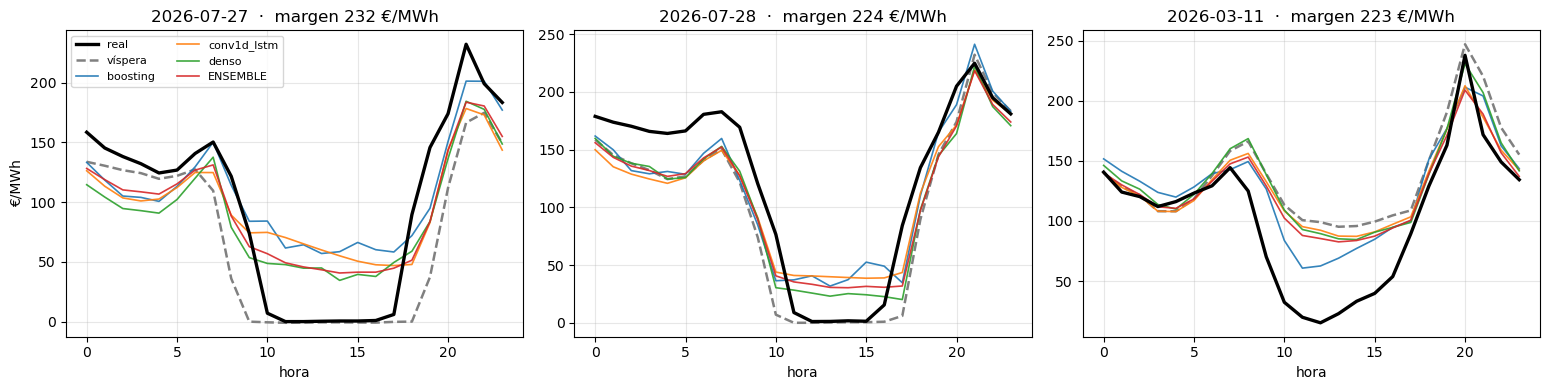

In [5]:
margen = Y.max(axis=1) - Y.min(axis=1)
dias = np.argsort(margen)[-3:][::-1]

fams = [f for f in preds if f != "ENSEMBLE"][:3] + (["ENSEMBLE"] if "ENSEMBLE" in preds else [])
fig, axes = plt.subplots(1, len(dias), figsize=(5.2 * len(dias), 4), sharey=False)
axes = np.atleast_1d(axes)
for ax, d in zip(axes, dias):
    ax.plot(Y[d], color="black", lw=2.4, label="real", zorder=5)
    ax.plot(NAIVE[d], color="grey", lw=1.8, ls="--", label="víspera")
    for fam in fams:
        ax.plot(preds[fam][d], lw=1.2, alpha=0.9, label=fam)
    ax.set_title(f"{fechas[d].date()}  ·  margen {margen[d]:.0f} €/MWh")
    ax.set_xlabel("hora"); ax.grid(alpha=0.3)
axes[0].set_ylabel("€/MWh"); axes[0].legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

## 5 · Habilidad hora a hora

La habilidad sobre la persistencia no se reparte por igual a lo largo del día. Lo esperable es
que sea baja en las horas planas de la madrugada —donde repetir la víspera ya funciona— y que
si el modelo aporta algo, aporte en el valle solar y en la rampa de la tarde.

Si el perfil es plano y próximo a cero en todas las horas, el modelo no aporta nada
estructural sobre la persistencia.

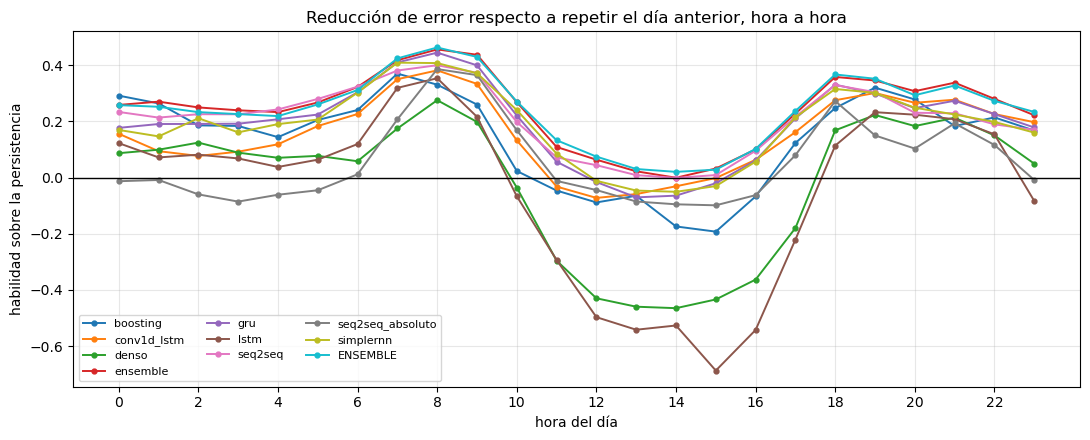

Por encima de 0 el modelo mejora a la persistencia en esa hora; por debajo, la empeora.


In [6]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for fam, P in preds.items():
    err_m = np.abs(P - Y).mean(axis=0)
    err_n = np.abs(NAIVE - Y).mean(axis=0)
    ax.plot(1 - err_m / err_n, marker="o", ms=3.5, lw=1.4, label=fam)
ax.axhline(0, color="black", lw=1)
ax.set_xlabel("hora del día"); ax.set_ylabel("habilidad sobre la persistencia")
ax.set_title("Reducción de error respecto a repetir el día anterior, hora a hora")
ax.set_xticks(range(0, 24, 2)); ax.grid(alpha=0.3); ax.legend(fontsize=8, ncol=3)
plt.tight_layout(); plt.show()

print("Por encima de 0 el modelo mejora a la persistencia en esa hora; por debajo, la empeora.")

## 6 · Lectura y decisión

Tres escenarios posibles, con la acción que corresponde a cada uno.

**Si la habilidad en forma es próxima a cero en todas las familias salvo la absoluta.**
Es la consecuencia esperada del objetivo residual: el modelo predice una corrección pequeña
sobre la víspera y la salida hereda su perfil. La familia absoluta, al no estar anclada, es la
única que puede aportar forma. Esto explica mecánicamente por qué el mejor modelo por error y
el mejor por captura no coinciden, y **es un resultado que debe ir a la memoria**: no es un
fallo, es la caracterización de un compromiso.

**Si la habilidad en forma es próxima a cero también en la familia absoluta.** Entonces el
problema no es la formulación del objetivo sino la información disponible. La comprobación
siguiente es que las previsiones estén alineadas al día objetivo y no al día de predicción:
si la previsión eólica de la fila correlaciona más con la generación real de D−1 que con la de
D+1, el modelo no tiene ninguna información sobre el día que debe predecir y copiar la víspera
es, literalmente, lo óptimo.

**Si la habilidad en forma es positiva y apreciable.** El modelo sí aporta, el parecido con la
víspera es el que le corresponde —los días consecutivos se parecen de verdad— y no hay
problema que resolver.

---

### Qué probar si el diagnóstico confirma el primer escenario

Ordenado por coste, y todo dentro de la arquitectura que ya existe.

**Enmascarar el precio de la víspera durante el entrenamiento.** Con una probabilidad del 30
al 50 % por lote, sustituir el canal del precio de D−1 por su valor medio. El modelo se ve
obligado a construir un camino alternativo con las variables exógenas. En inferencia se le
entrega siempre. Es un cambio de pocas líneas y suele ser lo que más mueve el resultado.

**Añadir una penalización sobre la forma en la función de pérdida.** Al error habitual se le
suma el error cometido sobre las desviaciones respecto a la media diaria, con un peso. Eso
obliga al modelo a gastar capacidad en la curva del día y no solo en el nivel.

**Separar las dos predicciones.** Una salida para el nivel, que sí recibe el precio de la
víspera, y otra para las 24 desviaciones normalizadas, que **no** lo recibe y se alimenta
únicamente de previsiones y calendario. Estructuralmente se le impide copiar el perfil, y la
descomposición coincide con la métrica económica.

**Y la línea futura, con nombre.** Las arquitecturas de series temporales que separan de forma
explícita covariables observadas hasta el instante actual de covariables conocidas para el
horizonte —el Temporal Fusion Transformer es el exponente canónico— resuelven este problema
por diseño: el decodificador recibe, en cada paso del horizonte, las previsiones
correspondientes a esa hora concreta. Un codificador-decodificador alimentado así ya tiene esa
forma; la cuestión es asegurarse de que las previsiones entran por el decodificador paso a
paso y no aplanadas por el codificador.